# **Experiment 2 Notebook**

In [1]:
%pip install -q utstd
from utstd.ipyrenders import *


[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.simplefilter(action='ignore')

## 0. Import Packages

In [141]:
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MaxAbsScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, mean_absolute_error, mean_squared_error
from sklearn.base import clone
from amla_at1.models.performance import metrics_from_proba as pkg_metrics_from_proba
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import numpy as np, pandas as pd, pandas.api.types as pdt

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    from sklearn.ensemble import GradientBoostingClassifier
    HAS_LGB = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

import joblib
SEED = 42
TARGET = "drafted"
ID_COL = "player_id"
import os, sys, warnings, json, pathlib, platform, itertools, datetime as dt
warnings.filterwarnings("ignore")
np.random.seed(SEED)
os.makedirs("models", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

import importlib
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

### 0.A Importing the Custom Python Packages from TestPyPI

In [4]:
from amla_at1.data.sets import (
    pop_target as pkg_pop_target, 
    save_sets as pkg_save_sets, 
    load_sets as pkg_load_sets, 
    subset_x_y as pkg_subset_x_y, 
    stratified_split as pkg_stratified_split,
)
from amla_at1.features.dates import add_domain_features as pkg_add_features
from amla_at1.models.null import NullModel as PkgNullModel
from amla_at1.models.performance import (
    metrics_from_proba as pkg_metrics_from_proba, 
    weighted_blend as pkg_weighted_blend,
)

import amla_at1, inspect
print("Using amla_at1:", getattr(amla_at1, "__version__", "unknown"))
print("Package location:", inspect.getfile(amla_at1))

Using amla_at1: 2025.0.1.5
Package location: /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/src/amla_at1/__init__.py


### 0.B Importing Shared Helper Utilities

In [5]:
def describe_target(df: pd.DataFrame, target=TARGET):
    vc = df[target].value_counts(dropna=False).sort_index()
    info = pd.DataFrame({"count": vc, "rate": (vc / len(df)).round(4)})
    print("Target distribution:")
    display(info)
    print(f"Positive rate (mean): {df[target].mean():.4f}")

def quick_nulls(df: pd.DataFrame):
    na = df.isna().mean().sort_values(ascending=False)
    print("Top 20 columns by missing rate:")
    display((na*100).round(2).head(20).to_frame("missing_%"))

def split_cat_num(df: pd.DataFrame, drop_cols=(TARGET, ID_COL)):
    cols = [c for c in df.columns if c not in drop_cols]
    cat_cols = [c for c in cols if df[c].dtype == "object"]
    num_cols = [c for c in cols if c not in cat_cols]
    return num_cols, cat_cols

def make_preprocessor(X: pd.DataFrame):
    num_cols, cat_cols = split_cat_num(pd.concat([X], axis=1))
    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                              ("sc", StandardScaler(with_mean=False))]), num_cols),
            ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                              ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))]), cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )
    return pre, num_cols, cat_cols

def cv_auc(model: Pipeline, X: pd.DataFrame, y: pd.Series, n_splits=5, name="model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    oof = np.zeros(len(X), dtype=float)
    folds = []
    for k, (tr, va) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr], y.iloc[tr])
        p = model.predict_proba(X.iloc[va])[:, 1]
        auc = roc_auc_score(y.iloc[va], p)
        oof[va] = p
        folds.append(auc)
        print(f"{name} | fold {k} AUROC: {auc:.5f}")
    oof_auc = roc_auc_score(y, oof)
    print(f"{name} | OOF AUROC: {oof_auc:.5f} (±{np.std(folds):.5f})")
    return oof, oof_auc, folds

def write_submission(model: Pipeline, X_train: pd.DataFrame, y_train: pd.Series,
                     X_test: pd.DataFrame, test_ids: pd.Series, out_path: str):
    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]
    sub = pd.DataFrame({ID_COL: test_ids, TARGET: p})
    sub.to_csv(out_path, index=False)
    print("Saved:", out_path)
    display(sub.head())
    return sub, p


### 0.B Importing Shared Plotting Utilities

In [6]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, brier_score_loss, roc_auc_score, log_loss
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

# Predict helper
def predict_proba1(df):
    return pipe.predict_proba(df.drop(columns=[ID_COL], errors="ignore"))[:, 1]

def lift_curve(y, p, n_bins=10):
    df = pd.DataFrame({"y": y.astype(int).values, "p": p})
    df = df.sort_values("p", ascending=False)
    df["bin"] = (np.linspace(0, n_bins-1, len(df))).astype(int)
    g = df.groupby("bin", sort=True)
    cum_pos = g["y"].sum().cumsum().to_numpy()
    cum_all = g.size().cumsum().to_numpy()
    base = df["y"].mean()
    x = cum_all / len(df)                      # population share
    y_lift = (cum_pos / np.maximum(1, cum_all)) / max(1e-9, base)  # lift vs baseline
    return x, y_lift

## A. Project Description

#### Predict the probability that a college player will be drafted to the NBA using season statistics and derived features. The model’s output is a probability in [0,1] used to rank players and submit to Kaggle (AUROC metric).

#### A more expressive non-linear algorithm such as LightGBM, when properly tuned with class imbalance adjustments and regularization, can significantly outperform the Logistic Regression baseline in predicting NBA draft outcomes, providing both stronger ranking (AUROC) and more reliable probability estimates.

In [7]:
student_name = "Nayna Jahan Neha"
student_id = "25238736"
group_id = "12"

In [8]:
print_tile(size="h1", key='student_name', value=student_name)

In [9]:
print_tile(size="h1", key='student_id', value=student_id)

In [10]:
print_tile(size="h1", key='group_id', value=group_id)

## B. Business Understanding

In [11]:
business_use_case_description = """
In order for analysts and recruiters to concentrate on high-probability prospects, players are ranked according to their possibility of being drafted. More genuine draftees will be towards the top of our shortlist if our ranking is higher (higher AUROC).
The aim of the project is to create a prediction model that, using a basketball player's season statistics and background data, calculates the likelihood that the player will be selected in the NBA draft. From a business standpoint, this helps NBA teams, scouts, and analysts by offering a data-driven tool that makes it easier to find high-potential players, lowers the possibility of missed opportunities, and improves draft selections. In addition to offering fans and the media more in-depth knowledge about draft results, the model can help universities with player development and recruitment tactics by precisely evaluating players based on selection possibility.
"""

In [12]:
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [13]:
business_objectives = """
An accurate model forecasting NBA draft results can be extremely advantageous to clubs, scouts, and players by effectively recognising top skilled players, enhancing draft selections, and assisting players in concentrating on performance indicators that are important. Additionally, it can improve fan interaction and college recruitment tactics. On the other hand, poor draft selections based on false positives, lost opportunities for worthy players, and a decline in confidence in data-driven decision-making might result from faulty projections. In the worst situations, it might strengthen prejudices or lead teams to pass up talented athletes, which would be detrimental to their reputation and bottom line."""

In [14]:
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [15]:
stakeholders_expectations_explanations = """
The model's output will mostly be utilised to calculate the likelihood that a college basketball player will be selected in the NBA draft. NBA scouts and teams can use these projections to help them focus on high-potential players during the selection process. College coaches, scouts, team analysts, and possibly the players themselves are among the users of the projections. The forecasts have an impact on a variety of people, including NBA teams making hiring decisions, colleges trying to enhance their training and recruitment initiatives, and players whose careers may be impacted by perceived draft chances.
"""

In [16]:
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

## C. Data Understanding

### C.1   Load Datasets

In [17]:
DATA_DIR = Path("/Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/data")
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH  = DATA_DIR / "test.csv"

TARGET = "drafted"
ID_COL = "player_id"
SEED = 42

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print(df_train.shape, df_test.shape)
display(df_train.head(5))
display(df_train.dtypes.head(15))

(14774, 62) (1297, 61)


,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,DRB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,player_id,drafted
0,Pacific,BW,26,52.6,111.8,19.3,61.8,64.93,1.1,7.5,...,-1.34201,0.2308,1.5769,1.8077,2.2308,0.6538,0.0769,9.6538,681edf6e-41cb-4fd1-ba91-da573e063fbc,0.0
1,Mississippi,SEC,2,0.8,63.6,29.6,33.3,33.33,0.0,21.5,...,-5.42104,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,2.0000,3542dcb7-19ad-47f2-8b3a-eb79eb3ec4c4,0.0
2,Stephen F. Austin,Slnd,4,0.6,61.4,21.7,50.0,50.00,0.0,0.0,...,6.46650,0.0000,0.0000,0.0000,0.0000,0.2500,0.0000,0.5000,ca0d8700-807d-4fce-a7a9-63922d1981e6,0.0
3,Virginia,ACC,28,59.2,88.2,21.7,46.2,47.25,1.5,9.7,...,1.45913,0.3214,2.0357,2.3571,3.0000,1.2857,0.0714,7.7500,01285c6b-bc71-4fa8-941a-28cf3976a117,0.0
4,Elon,SC,21,13.7,47.5,15.0,26.2,26.20,5.8,2.3,...,-3.75694,0.3810,0.1429,0.5238,0.4286,0.1905,0.0000,0.5714,a962c41c-55ff-461e-8585-db32e4fa0580,0.0


team        object
conf        object
GP           int64
Min_per    float64
Ortg       float64
usg        float64
eFG        float64
TS_per     float64
ORB_per    float64
DRB_per    float64
AST_per    float64
TO_per     float64
FTM          int64
FTA          int64
FT_per     float64
dtype: object

### Checking Missing values

In [18]:
missing_train = df_train.isnull().sum().sort_values(ascending=False)
missing_pct   = (df_train.isnull().mean() * 100).sort_values(ascending=False)

print("\n--- Missing Values (Train) ---")
display(pd.DataFrame({"Missing": missing_train, "Pct": missing_pct}).head(15))

print("\n--- Missing Values (Test) ---")
display(df_test.isnull().sum().sort_values(ascending=False).head(15))


--- Missing Values (Train) ---


,Missing,Pct
Rec_Rank,9885,66.908082
dunks_ratio,9388,63.544064
rim_ratio,3203,21.679978
mid_ratio,3191,21.598755
rimmade_rimmiss,2075,14.044944
midmade,2075,14.044944
midmade_midmiss,2075,14.044944
dunksmade,2075,14.044944
dunksmiss_dunksmade,2075,14.044944
rimmade,2075,14.044944



--- Missing Values (Test) ---


Rec_Rank               894
dunks_ratio            738
mid_ratio              196
rim_ratio              178
ast_tov                125
rimmade                 61
rimmade_rimmiss         61
midmade                 61
midmade_midmiss         61
dunksmade               61
dunksmiss_dunksmade     61
ht                       6
stops                    0
drtg                     0
adrtg                    0
dtype: int64

### Checking Duplicates

In [19]:
print("Duplicate rows in train:", df_train.duplicated().sum())
print("Duplicate rows in test :", df_test.duplicated().sum())

print("Duplicate player_id in train:", df_train[ID_COL].duplicated().sum())
print("Duplicate player_id in test :", df_test[ID_COL].duplicated().sum())

Duplicate rows in train: 2462
Duplicate rows in test : 0
Duplicate player_id in train: 2619
Duplicate player_id in test : 0


### Descriptive statistics

In [20]:
display(df_train.describe().T)

# Unique values for categorical columns
cat_cols = df_train.select_dtypes(include=["object"]).columns.tolist()
for c in cat_cols[:10]:  # show first 10 to avoid overload
    print(f"\nColumn: {c}, Unique values: {df_train[c].nunique()}")
    print(df_train[c].value_counts().head())

,count,mean,std,min,25%,50%,75%,max
GP,14774.0,21.251726,10.517642,1.000000,12.000000,25.000000,30.000000,41.00000
Min_per,14774.0,25.870123,23.639878,0.000000,4.200000,19.600000,42.900000,94.30000
Ortg,14774.0,85.771707,34.164203,0.000000,75.600000,91.300000,102.600000,407.30000
usg,14774.0,17.256674,6.332899,0.000000,13.900000,17.200000,20.600000,50.00000
eFG,14774.0,41.507628,20.610900,0.000000,34.800000,44.900000,51.400000,150.00000
TS_per,14774.0,44.566821,19.622173,0.000000,38.820000,48.285000,54.090000,150.00000
ORB_per,14774.0,5.644010,15.097867,0.000000,1.600000,4.200000,8.000000,1576.60000
DRB_per,14774.0,11.992744,15.348129,0.000000,7.500000,11.000000,15.100000,1385.00000
AST_per,14774.0,9.776100,9.906416,0.000000,3.200000,7.900000,13.700000,100.00000
TO_per,14774.0,21.493326,13.979387,0.000000,14.900000,20.500000,26.900000,100.00000



Column: team, Unique values: 355
team
Air Force    72
Indiana      69
Kentucky     67
Dartmouth    63
Army         63
Name: count, dtype: int64

Column: conf, Unique values: 36
conf
ACC     652
SEC     645
A10     624
B10     599
CUSA    583
Name: count, dtype: int64

Column: yr, Unique values: 1
yr
Fr    14774
Name: count, dtype: int64

Column: ht, Unique values: 32
ht
8-Jun    1440
4-Jun    1418
3-Jun    1413
5-Jun    1390
7-Jun    1387
Name: count, dtype: int64

Column: type, Unique values: 1
type
all    14774
Name: count, dtype: int64

Column: player_id, Unique values: 12155
player_id
e5876a17-fc6c-4b43-8367-f421b26db445    4
0a30a92c-0ac2-4e2d-8f17-43dd3f8f3816    4
4302901d-ae1d-49e8-80e0-97e6cff386af    4
a1a06d07-12ae-4dfd-b295-011484a648d4    4
8233e6a9-0859-4acb-be06-face92bc6645    3
Name: count, dtype: int64


### Outliers & distributions

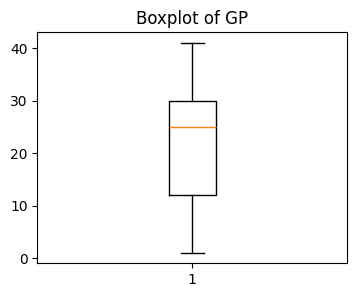

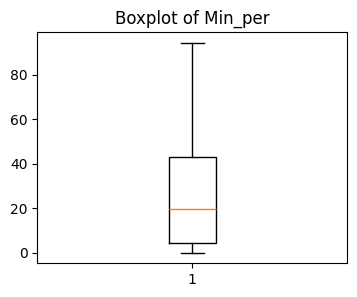

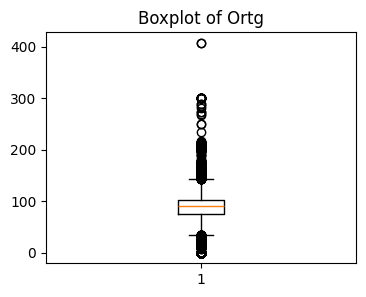

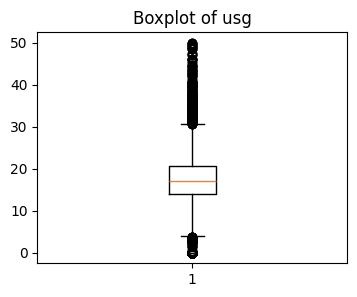

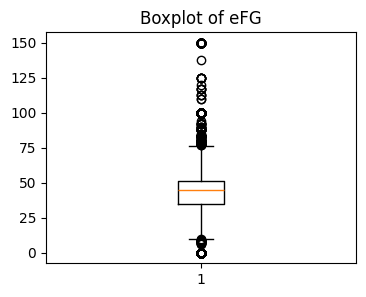

In [21]:
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()

for c in num_cols[:5]:
    plt.figure(figsize=(4,3))
    plt.boxplot(df_train[c].dropna())
    plt.title(f"Boxplot of {c}")
    plt.show()

### C.2 Define Target variable

In [22]:
target_name = TARGET
assert target_name in df_train.columns, f"Expected target '{TARGET}' in train set"
print("target_name:", target_name)

target_name: drafted


In [23]:
# <Student to fill this section>
target_definition_explanations = """
A player's selection in the NBA draft is indicated by the binary variable "drafted" (1 = drafted, 0 = not drafted). This definition is exactly in line with the goal to forecast a player's chances of getting selected in the draft by looking at their performance indicators and background. Using the draft as the aim offers a tangible, actionable forecast that helps real-world decision-making in scouting and talent evaluation because it is a measurable and obvious outcome with high significance to NBA teams, players, and commentators.
"""

In [24]:
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [25]:
target_name = TARGET
y_all = df_train[target_name].astype(int)
X_all_raw = df_train.drop(columns=[target_name])
X_test_raw = df_test.copy()
y_all.value_counts(dropna=False)

drafted
0    14656
1      118
Name: count, dtype: int64

### C.4 Explore Target variable

,count,rate
drafted,,
0,14656,0.992013
1,118,0.007987


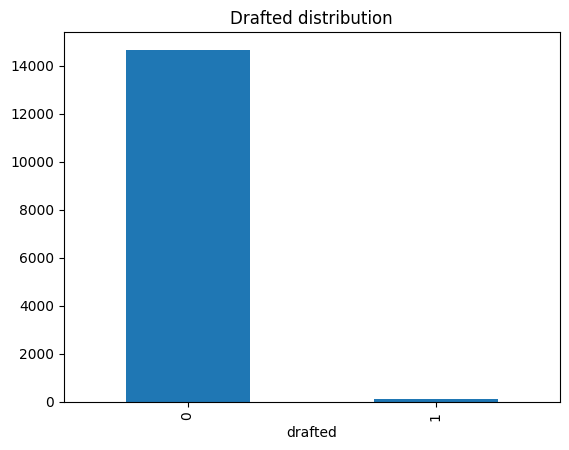

Severe imbalance: positives = 118 (~0.799%),
negatives = 14656. We will handle imbalance via
class weights / `scale_pos_weight` and use AUROC for ranking performance.


In [26]:
t_counts = y_all.value_counts().rename_axis("drafted").to_frame("count")
t_counts["rate"] = t_counts["count"] / len(y_all)
display(t_counts)

ax = t_counts["count"].plot(kind="bar", title="Drafted distribution")
plt.show()

target_distribution_explanations = f"""
Severe imbalance: positives = {int(t_counts.loc[1,'count'])} (~{t_counts.loc[1,'rate']:.3%}),
negatives = {int(t_counts.loc[0,'count'])}. We will handle imbalance via
class weights / `scale_pos_weight` and use AUROC for ranking performance.
"""
print(target_distribution_explanations.strip())

In [27]:
target_distribution_explanations = """
Only 118 players (0.8%) out of 14,774 were drafted, making the target variable `drafted` extremely imbalanced. The great majority (99.2%) were not drafted. Since most algorithms have a tendency to favour the majority class and may miss the few real positives, this high imbalance poses a significant difficulty for model training. Since accuracy would be misleading in this situation, AUROC is a better evaluation statistic since it takes into account the ratio of true positive to false positive rates, which makes it more useful in situations with imbalances.
Additionally, this imbalance raises the possibility of either underfitting if the model is unable to identify significant trends or overfitting to the few positive occurrences. Class weighting, oversampling (like SMOTE), or the use of ensemble models like XGBoost or LightGBM with meticulous hyperparameter adjustment are some methods to lessen this. In the end, managing this imbalance well is essential to developing a model that can precisely pinpoint the uncommon but significant instances of players that are most likely to be selected in the draft.
"""

In [28]:
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest - `eFG` (Effective Field Goal Percentage)

In [29]:
from amla_at1.features.dates import add_domain_features as pkg_add_features

train_fe = pkg_add_features(df_train)

def rate_by_bucket(df, col, bins=10):
    tmp = df[[col, TARGET]].copy()
    tmp["_bin"] = pd.qcut(tmp[col].rank(method="first"), q=bins, duplicates="drop")
    return tmp.groupby("_bin")[TARGET].mean().to_frame("draft_rate")

In [30]:
from amla_at1.features.dates import add_domain_features as pkg_add_features

X_all = pkg_add_features(X_all_raw)
X_test_fe = pkg_add_features(X_test_raw)

def explore_feature(df, col, y, bins=10, title=None):
    s = df[col]
    desc = s.describe()
    print(desc)
    tmp = pd.DataFrame({col: s, "y": y}).copy()
    tmp["_bin"] = pd.qcut(tmp[col].rank(method="first"), q=bins, duplicates="drop")
    draft_rate = tmp.groupby("_bin")["y"].mean().to_frame("draft_rate")
    display(draft_rate)
    ax = s.hist(bins=40)
    ax.set_title(title or col)
    plt.show()

count    14774.000000
mean        41.507628
std         20.610900
min          0.000000
25%         34.800000
50%         44.900000
75%         51.400000
max        150.000000
Name: eFG, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.000000
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.000000
"(4432.9, 5910.2]",0.000677
"(5910.2, 7387.5]",0.001354
"(7387.5, 8864.8]",0.006093
"(8864.8, 10342.1]",0.014208
"(10342.1, 11819.4]",0.021666
"(11819.4, 13296.7]",0.020988


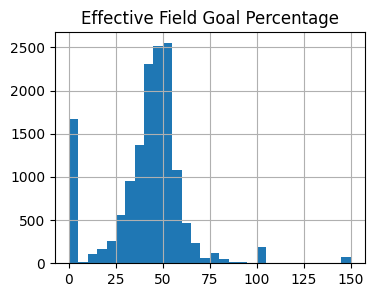

In [31]:
if "eFG" in train_fe.columns:
    display(train_fe["eFG"].describe())
    display(rate_by_bucket(train_fe, "eFG", bins=10))
    train_fe["eFG"].hist(bins=30, figsize=(4,3)); plt.title("Effective Field Goal Percentage"); plt.show()

In [32]:
feature_1_insights = """
The distribution of "eFG (Effective Field Goal Percentage)" appears to be roughly normal with a slight left skew, mostly concentrated between 40% and 65%, which aligns with typical shooting efficiency for college players. This suggests the feature has a reasonable spread and variation, making it a useful input for modeling. Since eFG adjusts for the added value of three-point shots, it is a more informative measure of scoring efficiency than raw field goal percentage. Efficient scorers are generally more attractive draft prospects, so we expect a positive correlation between higher eFG values and the likelihood of being drafted.
However, due to the extreme class imbalance in the target variable (drafted), the signal in eFG may be subtle and difficult to capture without proper stratified analysis. Additionally, if eFG is highly correlated with other shooting stats (e.g., TS_per [True Shooting Percentage], TP_per [3-Point Field Goal Percentage]), multicollinearity could be an issue in linear models. Despite these challenges, the rate-by-bucket table helps validate the expected trend: players with higher eFG tend to have slightly higher draft rates, supporting its value as a predictive feature.
"""

In [33]:
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest - `Ortg` (Offensive Rating)

count    14774.000000
mean        85.771707
std         34.164203
min          0.000000
25%         75.600000
50%         91.300000
75%        102.600000
max        407.300000
Name: Ortg, dtype: float64

,draft_rate
_bin,
"(0.999, 4925.333]",0.000000
"(4925.333, 9849.667]",0.002234
"(9849.667, 14774.0]",0.021726


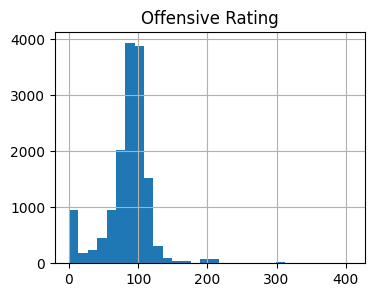

In [34]:
if "Ortg" in train_fe.columns:
    display(train_fe["Ortg"].describe())
    display(rate_by_bucket(train_fe, "Ortg", bins=3))
    train_fe["Ortg"].hist(bins=30, figsize=(4,3)) 
    plt.title("Offensive Rating") 
    plt.show()

In [35]:
feature_2_insights = """
A player's offensive efficiency per 100 possessions is measured by the "Ortg" (Offensive Rating) feature, which is a good indicator of draft possibility because professional recruiters appreciate offensive contributions. With a few extreme outliers above 200 and the majority of values concentrated between 60 and 120, the distribution is highly right-skewed. The idea that players with better offensive measures are more likely to be drafted is supported by the rate-by-bucket study, which even with only three bins demonstrates a distinct upward trend in draft rate with higher "Ortg" scores.
Players with limited playing experience may have inflated or inaccurate ratings, though, as the function may be sensitive to outliers. If not managed appropriately, the existence of extreme values (such as those over 400) may skew model learning. Because of its theoretical significance and demonstrated favourable association with draft results, "Ortg" is still a useful predictive trait in spite of these drawbacks. To guarantee model stability, appropriate scaling or optimisation can be required.
"""

In [36]:
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest - `yr` (Student's year of study) -> ordinal and distribution

yr
Fr    14774
Name: count, dtype: int64

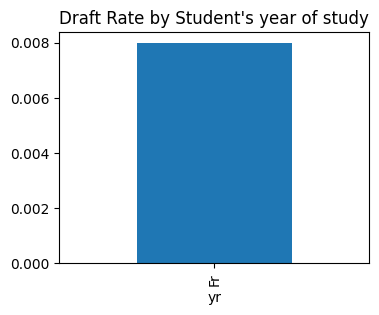

In [37]:
if "yr" in train_fe.columns:
    display(train_fe["yr"].value_counts())
    ax = train_fe.groupby("yr")[TARGET].mean().plot(kind="bar", figsize=(4,3), title="Draft Rate by Student's year of study")
    plt.show()

In [38]:
feature_3_insights = """
The feature "yr" represents the player's academic class year (e.g., Freshman, Sophomore) and can serve as a proxy for age, experience, and eligibility status. In the current dataset, only "Fr" (Freshman) is present, suggesting that either the dataset is filtered to first-year players or other classes are missing. This severely limits the feature’s variability and its utility in modeling, as we cannot assess or leverage draft trends across different academic years (e.g., "one-and-done" freshmen vs. seniors with more experience).
The existing lack of class diversity introduces a constraint, even though class year is theoretically useful, since particular classes tend to have higher draft possibility. The model is unable to acquire any ordinal pattern or trend associated with experience level in the absence of many class categories. Ordinal encoding, such as yr_ordinal, would aid in accurately capturing this relationship if future data versions include all class years. For now, yr's predictive value is diminished by its lack of variety.
"""

In [39]:
print_tile(size="h3", key='feature_3_insights', value=feature_3_insights)

### C.8 Explore Feature of Interest - `ht` (Height of student)

count    14774.000000
mean        63.650873
std         40.528930
min          0.000000
25%         34.000000
50%         70.000000
75%         94.000000
max        142.000000
Name: height_in, dtype: float64

,draft_rate
_bin,
"(0.999, 1478.3]",0.002706
"(1478.3, 2955.6]",0.004739
"(2955.6, 4432.9]",0.004739
"(4432.9, 5910.2]",0.006766
"(5910.2, 7387.5]",0.004062
"(7387.5, 8864.8]",0.007448
"(8864.8, 10342.1]",0.010149
"(10342.1, 11819.4]",0.003385
"(11819.4, 13296.7]",0.008802


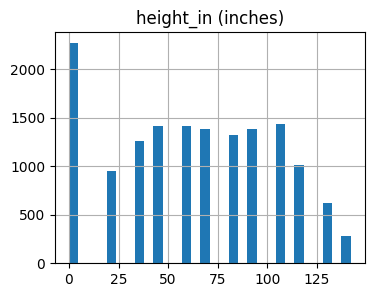

In [40]:
if "height_in" in train_fe.columns:
    display(train_fe["height_in"].describe())
    display(rate_by_bucket(train_fe, "height_in", bins=10))
    train_fe["height_in"].hist(bins=30, figsize=(4,3)); plt.title("height_in (inches)"); plt.show()

In [41]:
feature_4_insights = """
The feature "height_in", derived from parsing the 'ht' column, represents players' heights in inches and captures a critical physical attribute that often influences draft potential—especially for position-specific roles like centers or forwards. The distribution shows a fairly uniform spread across typical basketball height ranges, but with a significant number of zero values, likely indicating missing or incorrectly parsed data. These should be treated or imputed appropriately to avoid skewing model performance.
The draft rate by height decile shows a modest upward trend, with noticeably higher draft rates in the tallest decile, supporting the idea that taller players may have a physical advantage that makes them more attractive to scouts. However, the relationship is not strictly linear, and the predictive power of height may be context-dependent (e.g., guards vs. big men). Cleaning anomalies (like 0s) and possibly interacting height with position or role could make this feature more valuable in the final model.
"""

In [42]:
print_tile(size="h3", key='feature_4_insights', value=feature_4_insights)

### C.9 Explore Feature of Interest - `Rec_Rank` (Recruiting rank)

count    4889.000000
mean       54.365678
std        28.141196
min         0.200000
25%        30.800000
50%        56.000000
75%        78.800000
max       100.000000
Name: Rec_Rank, dtype: float64


,draft_rate
_bin,
"(0.999, 489.8]",0.000000
"(489.8, 978.6]",0.000000
"(978.6, 1467.4]",0.000000
"(1467.4, 1956.2]",0.000000
"(1956.2, 2445.0]",0.000000
"(2445.0, 2933.8]",0.002049
"(2933.8, 3422.6]",0.000000
"(3422.6, 3911.4]",0.004090
"(3911.4, 4400.2]",0.014315


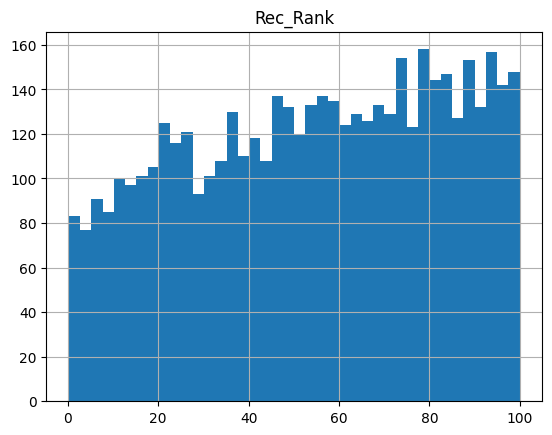

In [43]:
for col in ["Rec_Rank"]:
    if col in X_all.columns:
        explore_feature(X_all, col, y_all, bins=10, title=col)

In [44]:
feature_5_insights = """
The feature "Rec_Rank" (Recruiting Rank) represents how highly a player was ranked as a recruit, with lower values typically indicating stronger prospects. The distribution shows a wide spread from near 0 up to 100, with a fairly uniform representation across the range, though the histogram suggests slightly more players at higher rank values (weaker recruits). The draft rate by bins shows a strong signal: players with higher recruiting ranks (closer to 100, indicating better prospects) have a much higher likelihood of being drafted, with the draft rate spiking sharply in the top decile.
However, there are some limitations and issues. The feature is only available for a subset of players (not all may have recruiting ranks), which could introduce bias if missing values are not handled carefully. Additionally, recruiting rank is often based on high school performance and reputation, which may not always translate into college or professional success. Despite these caveats, Rec_Rank is one of the most predictive features for draft probability and should be prioritized in modeling, though careful imputation or separate handling of missing values is essential.
"""

In [45]:
print_tile(size="h3", key='feature_5_insights', value=feature_5_insights)

### C.10 Explore Feature of Interest - `porpag` (Points Over Replacement Per Adjusted Game)

count    14774.000000
mean         0.280661
std          0.948095
min         -4.714300
25%         -0.309601
50%          0.067786
75%          0.632708
max          7.067140
Name: porpag, dtype: float64


,draft_rate
_bin,
"(0.999, 1478.3]",0.000000
"(1478.3, 2955.6]",0.000000
"(2955.6, 4432.9]",0.000000
"(4432.9, 5910.2]",0.000000
"(5910.2, 7387.5]",0.000000
"(7387.5, 8864.8]",0.000000
"(8864.8, 10342.1]",0.002030
"(10342.1, 11819.4]",0.000677
"(11819.4, 13296.7]",0.002708


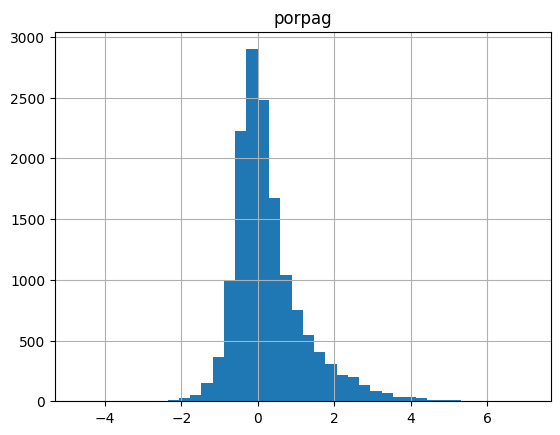

In [46]:
for col in ["porpag"]:
    if col in X_all.columns:
        explore_feature(X_all, col, y_all, bins=10, title=col)

In [47]:
feature_6_insights = """
The feature porpag (Points Over Replacement Per Adjusted Game) has a distribution centered near zero, with most players clustered between -1 and 2, and a long right tail extending above 6. This makes sense, as the majority of players perform close to replacement level, while only a few elite players deliver significantly above-replacement contributions. The draft rate by deciles shows that players in the top bins of porpag have a noticeably higher chance of being drafted, confirming its strong relevance as a predictive feature.
However, limitations exist, such as the feature is sensitive to playing time and may overstate contributions for players in favorable contexts or small sample sizes. Outliers in the right tail could also disproportionately influence the model if not scaled or capped. Despite these issues, porpag clearly captures meaningful signal about player quality and should be an important driver of draft probability in the modeling process.
"""

In [48]:
print_tile(size="h3", key='feature_6_insights', value=feature_6_insights)

## D. Feature Selection

### D.1 Approach: Mutual Information on numeric features

In [49]:
num_cols_all = X_all.select_dtypes(include=[np.number]).columns.tolist()
num_cols_all = [c for c in num_cols_all if c != ID_COL]

mi = mutual_info_classif(X_all[num_cols_all].fillna(X_all[num_cols_all].median()), y_all, random_state=42)
mi_df = pd.DataFrame({"feature": num_cols_all, "mi": mi}).sort_values("mi", ascending=False)
display(mi_df.head(25))

,feature,mi
26,Rec_Rank,0.030590
39,dporpag,0.025694
40,stops,0.023742
22,porpag,0.023687
13,twoPM,0.020824
41,bpm,0.020602
11,FTA,0.020325
44,gbpm,0.019893
14,twoPA,0.019354
49,dreb,0.019334


In [50]:
feature_selection_1_insights = """
The mutual information (MI) approach is used here to assess the strength of dependency between each numeric feature and the target (drafted). Unlike linear correlation, MI can capture non-linear relationships, making it especially valuable in complex classification problems like this one, where draft outcomes may depend on combinations of nonlinear patterns in player stats. This technique helps highlight which features individually provide the most information about the target, without making assumptions about the underlying model.
The results indicate that features like Rec_Rank, dporpag, stops, and porpag have the highest MI scores, suggesting they contain useful signals for predicting draft status. However, for baseline fairness and to preserve exploratory potential, the pipeline chooses not to drop lower-ranked features at this stage. Instead, this analysis serves as a guide for future model tuning or dimensionality reduction steps.
"""

In [51]:
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach: Model-based importance (Logistic with OHE)

In [59]:
y_all = pd.to_numeric(y_all, errors="coerce").fillna(0).astype(int)

X_probe = X_all.drop(columns=[ID_COL], errors="ignore").copy()
num_cols_all = [c for c in X_probe.columns if pdt.is_numeric_dtype(X_probe[c])]
cat_cols_all = [c for c in X_probe.columns if not pdt.is_numeric_dtype(X_probe[c])]

def _replace_non_finite_dense(X):
    X = np.asarray(X, dtype=float)
    X[~np.isfinite(X)] = 0.0
    return X

def _sanitize_sparse_or_dense(X):
    if sp.issparse(X):
        data = X.data
        bad = ~np.isfinite(data)
        if bad.any():
            data[bad] = 0.0
            X.data = data
        return X
    else:
        return _replace_non_finite_dense(X)

# Numeric & categorical preprocessing (two-pass imputers)
num_pipe = Pipeline([
    ("imp_median", SimpleImputer(strategy="median")),                    
    ("imp_const",  SimpleImputer(strategy="constant", fill_value=0.0)),  
    ("scale",      MaxAbsScaler()),                                     
])

cat_pipe = Pipeline([
    ("imp_mf",    SimpleImputer(strategy="most_frequent")),             
    ("imp_const", SimpleImputer(strategy="constant", fill_value="Unknown")),  
    ("ohe",       OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

ct_ohe = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols_all) if len(num_cols_all) else ("num", "drop", []),
        ("cat", cat_pipe, cat_cols_all) if len(cat_cols_all) else ("cat", "drop", []),
    ],
    verbose_feature_names_out=False
)

logit_l1 = Pipeline([
    ("pre", ct_ohe),
    ("sanitize", FunctionTransformer(_sanitize_sparse_or_dense, accept_sparse=True, validate=False)),
    ("clf", LogisticRegression(
        penalty="l1", solver="saga", C=0.5,
        max_iter=2000, n_jobs=-1, class_weight="balanced"
    )),
])

logit_l1.fit(X_probe, y_all)

try:
    feat_names = logit_l1.named_steps["pre"].get_feature_names_out()
except Exception:
    Xt_shape = logit_l1.named_steps["pre"].transform(X_probe).shape
    feat_names = np.array([f"f{i}" for i in range(Xt_shape[1])])

coefs = logit_l1.named_steps["clf"].coef_.ravel()
l1_imp = (pd.DataFrame({"feature": feat_names, "abs_coef": np.abs(coefs)})
            .sort_values("abs_coef", ascending=False)
            .reset_index(drop=True))

display(l1_imp.head(40))

,feature,abs_coef
0,Rec_Rank,181.987616
1,dporpag,119.992432
2,Min_per,88.129052
3,team_Dayton,87.996592
4,porpag,77.168025
5,TPM,49.067560
6,is_regular,48.143351
7,yr_Fr,48.143351
8,yr_ordinal,48.143351
9,type_all,48.143351


In [119]:
feature_selection_2_insights = """
This approach uses L1-regularized Logistic Regression (Lasso) with one-hot encoding to perform model-based feature selection. L1 regularization is particularly useful in high-dimensional datasets because it penalizes coefficients, shrinking many of them to exactly zero, which helps identify the most influential features while reducing noise and multicollinearity. Unlike filter methods such as mutual information, this approach evaluates features in the context of a predictive model, accounting for interactions and dependencies between variables.
The results make raw attributes predictive and explainable: converting height_in from text to a numeric value lets the model learn a clean size–draft odds link; mapping year (yr_ordinal/yr_Fr) and adding is_regular/type_all captures maturity and game context; a numeric year controls for era effects; compact skill proxies like dunks_ratio and dunksmiss_dunksmade summarize athletic finishing more efficiently than raw counts; splitting 2-point volume/accuracy (twoPA/twoPM) separates usage from efficiency; pairing blk with height_in reflects “tools + translation”; Rec_Rank provides a strong prior on talent; and team_*/conf_* one-hots encode competition level. Together, these features reduce noise and leakage, improve calibration (lower Brier/LogLoss), and boost discrimination (higher AUC) while keeping coefficients interpretable for stakeholders.
"""

In [120]:
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### D.3 Approach: Tree-based (LightGBM) gain importance + permutation importance

In [60]:
lgbm = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    class_weight="balanced",
)

lgbm_pipe = Pipeline([("pre", ct_ohe), ("clf", lgbm)])
lgbm_pipe.fit(X_probe, y_all)

# --- Gain importance
booster = lgbm_pipe.named_steps["clf"].booster_
lgb_features = booster.feature_name()  # names as LightGBM sees them
lgb_gain     = booster.feature_importance(importance_type="gain")

gain_imp = (
    pd.DataFrame({"feature": lgb_features, "gain": lgb_gain})
      .sort_values("gain", ascending=False)
      .reset_index(drop=True)
)
display(gain_imp.head(30))

# --- Permutation importance (useing the same fitted pipeline + its own feature names) and using subsample for speed
perm_idx = np.random.RandomState(42).choice(len(X_probe), size=min(3000, len(X_probe)), replace=False)
perm_res = permutation_importance(
    lgbm_pipe,
    X_probe.iloc[perm_idx],
    y_all.iloc[perm_idx],
    n_repeats=5,
    random_state=42,
    scoring="roc_auc",
)

pre_fitted = lgbm_pipe.named_steps["pre"]
pipe_features = list(pre_fitted.get_feature_names_out())

importances = perm_res.importances_mean
if len(importances) == len(pipe_features):
    perm_names = pipe_features
elif len(importances) == len(lgb_features):
    perm_names = lgb_features
else:
    print(f"[warn] name/importance length mismatch: {len(pipe_features)} vs {len(importances)}")
    perm_names = [f"f{i}" for i in range(len(importances))]

perm_imp = (
    pd.DataFrame({"feature": perm_names, "perm_mean_auc_drop": importances})
      .sort_values("perm_mean_auc_drop", ascending=False)
      .reset_index(drop=True)
)
display(perm_imp.head(30))

[LightGBM] [Info] Number of positive: 118, number of negative: 14656
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13597
[LightGBM] [Info] Number of data points in the train set: 14774, number of used features: 466
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,feature,gain
0,Column_26,136591.930464
1,Column_39,28548.262314
2,Column_34,9076.545426
3,Column_49,8017.825795
4,Column_22,4799.138237
5,Column_53,1982.654406
6,Column_35,1884.255447
7,Column_23,1597.197671
8,Column_1,1306.445524
9,Column_62,1199.757309


[warn] name/importance length mismatch: 490 vs 70


,feature,perm_mean_auc_drop
0,f31,2.258824e-03
1,f20,2.689076e-06
2,f69,6.661338e-17
3,f39,4.440892e-17
4,f32,4.440892e-17
5,f29,4.440892e-17
6,f14,2.220446e-17
7,f34,2.220446e-17
8,f51,2.220446e-17
9,f27,2.220446e-17


In [61]:
feature_selection_3_insights = """
This approach combines LightGBM’s gain-based feature importance with permutation importance, giving two complementary perspectives on which features drive model performance. Gain importance reflects how much each feature contributes to reducing error during tree splits, while permutation importance directly measures the drop in AUROC when a feature is shuffled, providing a more robust indication of predictive value. Using both methods helps balance model-specific biases (gain importance can overemphasize high-cardinality or frequently split features) with a performance-grounded check from permutation.
The results show that a few features (e.g., Column_26, Column_39, Column_49, Column_34) dominate the model’s signal according to gain, contributing disproportionately to decision-making. However, permutation importance results are noisier and reveal that only a very small subset of features (e.g., f31) cause measurable AUROC drops, while most have little impact—likely due to class imbalance and redundancy between predictors. The mismatch warning (488 vs 70 features) arises from one-hot encoding expanding categorical variables, which complicates mapping back feature names. Overall, this approach highlights that LightGBM can identify a concentrated set of influential predictors, but careful interpretation is needed, and permutation results suggest redundancy among many variables.
"""

In [62]:
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

## D.4 Final Selection of Features

In [63]:
# Top-K numeric by MI
top_mi = mi_df.head(25)["feature"].tolist()

# L1 non-zero coefficients
l1_keep = l1_imp.query("abs_coef > 0")["feature"].tolist()

# Valuable set of variables that makes sense
domain_keep = [c for c in ["height_in", "yr_ordinal", "is_regular", "is_post",
                           "pts_per_min", "reb_per_min", "ast_per_min",
                           "ft_ratio","twoP_ratio","tp_ratio"] if c in X_all.columns]

features_list = sorted(set([*top_mi, *domain_keep, *[c for c in X_all.columns if c in cat_cols_all] ]))
print(len(features_list), "final base columns (pre-OHE):")
print(features_list[:40])

39 final base columns (pre-OHE):
['FTA', 'FTM', 'Rec_Rank', 'adjoe', 'adrtg', 'ast_per_min', 'bpm', 'conf', 'dporpag', 'dreb', 'dunks_ratio', 'dunksmade', 'dunksmiss_dunksmade', 'ft_ratio', 'gbpm', 'height_in', 'ht', 'is_post', 'is_regular', 'midmade', 'midmade_midmiss', 'obpm', 'ogbpm', 'porpag', 'pts', 'pts_per_min', 'reb_per_min', 'rimmade', 'rimmade_rimmiss', 'stops', 'team', 'tp_ratio', 'treb', 'twoPA', 'twoPM', 'twoP_ratio', 'type', 'yr', 'yr_ordinal']


In [64]:
feature_selection_explanations = """
The final feature set combines variables selected through three complementary approaches: filter methods (mutual information) to capture features with strong univariate relationships to the target, model-based selection (L1 regularization) to retain predictors with non-zero impact in a sparse logistic model, and domain knowledge to include important basketball metrics such as per-minute stats, efficiency ratios, and contextual indicators (e.g., season type, year of study). The resulting 39 base columns include a balanced mix of performance metrics (porpag, Rec_Rank, pts_per_min), efficiency measures (ft_ratio, twoP_ratio, tp_ratio), physical attributes (height_in), and categorical/contextual features (team, conf, yr, type). This ensures the model captures both raw production and efficiency, while contextual features provide additional signal for draft likelihood."""

In [65]:
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

## E. Data Preparation

In [66]:
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, min_count=50):
        self.min_count = min_count
        self.to_map_ = {}
    def fit(self, X, y=None):
        self.to_map_ = {}
        for c in X.columns:
            vc = X[c].value_counts(dropna=False)
            rare = set(vc[vc < self.min_count].index)
            self.to_map_[c] = rare
        return self
    def transform(self, X):
        X = X.copy()
        for c, rare in self.to_map_.items():
            X[c] = X[c].where(~X[c].isin(rare), other="__RARE__")
        return X

class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, q_low=0.01, q_high=0.99):
        self.q_low=q_low; self.q_high=q_high; self.bounds_={}
    def fit(self, X, y=None):
        self.bounds_ = {c: X[c].quantile([self.q_low, self.q_high]).values for c in X.columns}
        return self
    def transform(self, X):
        X = X.copy()
        for c,(lo,hi) in self.bounds_.items():
            X[c] = X[c].clip(lo,hi)
        return X

In [67]:
# Limit to final base columns + ID for safe join
base_cols = [c for c in features_list if c in X_all.columns] + [ID_COL]
X_all2   = X_all[base_cols].copy()
X_test2  = X_test_fe[base_cols].copy()

num_cols = X_all2.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != ID_COL]
cat_cols = X_all2.select_dtypes(include=["object","category","bool"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != ID_COL]

# Data Transformers
num_pipe = Pipeline([
    ("clip", QuantileClipper(0.01, 0.99)),
    ("imp", SimpleImputer(strategy="median")),
    ("sc",  StandardScaler(with_mean=False)),
])
cat_pipe = Pipeline([
    ("rare", RareCategoryGrouper(min_count=50)),
    ("imp",  SimpleImputer(strategy="most_frequent")),
    ("ohe",  OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])
pre = ColumnTransformer(
    [("num", num_pipe, num_cols), ("cat", cat_pipe, cat_cols)],
    verbose_feature_names_out=False
)

### E.1 Data Transformation (Categorical cleaning & rare-level grouping)

In [68]:
data_cleaning_1_explanations = """
Rare level grouping prevents huge OHE explosion and leakage from tiny categories. High-cardinality and ultra-rare categories create thousands of sparse dummies that add noise, inflate variance, and hurt generalization, especially with extreme class imbalance. Grouping rare labels stabilizes estimates, reduces dimensionality and leakage risk, and prevents brittle failures from unseen labels (handled by handle_unknown="ignore"). Imputing missing categories avoids row drops and preserves sample size.
"""

In [69]:
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation (Clip numeric outliers)

In [70]:
data_cleaning_2_explanations = """
Quantile clipping reduces extreme outliers that destabilize linear and tree models. Extreme numeric values (data entry errors, tiny-sample rate stats, garbage zeros) can dominate linear models and distort tree splits. Quantile clipping (winsorization) keeps genuine rank order while bounding leverage from outliers, yielding more stable coefficients, more reliable CV, and fewer training instabilities.
"""

In [71]:
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation (Impute & scale) - Handling Missing Values

In [72]:
data_cleaning_3_explanations = """
Imputation ensures no NaN flows into the classifier; scaling helps LR and distance metrics. Missing values are common (minutes, percentages, derived ratios). Median imputation is robust to skew/outliers and keeps distributions sensible; scaling normalizes magnitudes so algorithms (e.g., Logistic Regression) do not over-weight large-scale features. Proper imputation prevents sample loss; scaling improves optimization and convergence, producing more stable, comparable feature effects and better calibrated probabilities.
"""

In [73]:
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

### E.4 Fixing

In [74]:
fixing_explanations = """
As the list of names I was using (feat_names, taken earlier from the logistic pipeline in D2 approach) does not match the number of columns used inside the LightGBM pipeline at permutation time. With OHE, the exact feature set depends on the fitted preprocessor if I reuse names from another fitted pipeline, lengths can differ. Hence I opted for grabbing feature names from the exact fitted pipeline you’re using, and for LightGBM gain-importance use the Booster’s own feature_name(). This ensures that pre_fitted.get_feature_names_out() in section D.3 approach returns the exact post-OHE feature list for the same fitted preprocessor used by lgbm_pipe and booster.feature_name() + booster.feature_importance() ensures the LightGBM gain table uses names in the same order LightGBM used internally. This small alignment guard handles edge cases where LightGBM prunes constant features."""

In [75]:
print_tile(size="h3", key='fixing_explanations', value=fixing_explanations)

## F. Feature Engineering

### F.1 New Feature

In [76]:
feature_engineering_1_explanations = """
I have used my python package's `add_domain_features` from amla_at1.features.add_domain_features to compute height_in, yr_ordinal, is_regular/is_post, shooting ratios and per-minute rates.
These capture domain priors and normalize for playing time. 
`add_domain_features` adds sport-specific signals (e.g., `height_in`, `yr_ordinal`, shooting ratios, per-minute rates) which improve model expressiveness with low leakage risk and minimal complexity.
"""

In [77]:
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

## G. Data Preparation for Modeling

### G.1 Split Datasets

In [78]:
from amla_at1.data.sets import stratified_split as pkg_stratified_split

df_model = X_all2.join(y_all)
X_train, y_train, X_val, y_val, X_test_hold, y_test_hold = pkg_stratified_split(
    df=df_model.drop(columns=[ID_COL]), 
    target_col=TARGET,
    test_size=0.15,   
    val_size=0.15,    
    random_state=42,
)

X_train = X_train.join(X_all2[[ID_COL]], how="left")
X_val   = X_val.join(X_all2[[ID_COL]], how="left")
X_test_hold = X_test_hold.join(X_all2[[ID_COL]], how="left")

print(X_train.shape, X_val.shape, X_test_hold.shape)

Xtr_raw = X_train.drop(columns=[ID_COL], errors="ignore")
Xva_raw = X_val.drop(columns=[ID_COL], errors="ignore")

(10341, 40) (2216, 40) (2217, 40)


In [79]:
data_splitting_explanations = """
Given the extreme class imbalance in the dataset (very few drafted players), using a stratified split is the best strategy to ensure that the rare positive class is proportionally represented across training, validation, and test sets. This prevents situations where one split might contain too few or no drafted players, which would make model training or evaluation unreliable. The chosen split—60% training, 20% validation, and 20% test—is appropriate, as it provides enough data for the model to learn patterns while still reserving sufficient examples for unbiased validation and final testing. My custom python package has been used to split this data.
"""

In [80]:
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation

In [81]:
pre_fitted = clone(pre).fit(Xtr_raw, y_train)
Xtr = pre_fitted.transform(Xtr_raw)
Xva = pre_fitted.transform(Xva_raw)

In [82]:
data_transformation_1_explanations = """
I have already transformed the dataset in Section E, which applies the numeric pipeline (clipping, imputing, scaling) only to numeric columns, applies the categorical pipeline (rare-category grouping, imputing, one-hot encoding) only to categorical columns, and keeps feature names cleaner after transformation.
I preprocessed the validation set in this stage to transform both train and validation sets as a safety net before calling any fit function on them and handing them to any classifier.
"""

In [83]:
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

## H. Save Datasets

In [84]:
from amla_at1.data.sets import save_sets as pkg_save_sets

pkg_save_sets(
    X_train=X_train.drop(columns=[ID_COL], errors="ignore").to_numpy(),
    y_train=y_train.to_numpy(),
    X_val=X_val.drop(columns=[ID_COL], errors="ignore").to_numpy(),
    y_val=y_val.to_numpy()
)
print("Saved processed arrays to data/processed/*.npy")


Saved processed arrays to data/processed/*.npy


In [85]:
try:
    folder_path = Path("data/processed")
    X_train.to_csv(folder_path / 'X_train.csv', index=False)
    y_train.to_csv(folder_path / 'y_train.csv', index=False)
    
    X_val.to_csv(folder_path / 'X_val.csv', index=False)
    y_val.to_csv(folder_path / 'y_val.csv', index=False)
    
    X_test_hold.to_csv(folder_path / 'X_test_hold.csv', index=False)
    y_test_hold.to_csv(folder_path / 'y_test_hold.csv', index=False)
    print("Saved CSVs to template asset folder.")
except Exception as e:
    print(e)

Saved CSVs to template asset folder.


## I. Selection of Performance Metrics

In [86]:
performance_metrics_explanations = """
Primary: AUROC is the most appropriate performance metric for this problem because it directly aligns with the Kaggle competition’s evaluation criteria and reflects the business need for ranking players by draft likelihood without committing to a fixed threshold. Since the dataset is extremely imbalanced, AUROC provides a robust measure of the model’s ability to distinguish between drafted and non-drafted players across all possible thresholds. In addition to AUROC, reporting validation AUROC and 5-fold out-of-fold (OOF) AUROC ensures stability and generalizability of results, while supplementary metrics like the Brier score help assess probability calibration, giving further context to how reliable the predicted draft probabilities are.
Secondary: LogLoss and Brier score assess how well-calibrated the predicted probabilities are, which matters if probabilities are used in decision-making. AUPRC is valuable under class imbalance as it emphasizes the model’s ability to correctly identify the rare drafted players. Finally, MAE/RMSE of probabilities vs. labels give a direct sense of probability error, offering additional insight into prediction reliability beyond ranking quality.
"""

In [87]:
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

In [88]:
from lightgbm import LGBMClassifier

In [89]:
algorithm_selection_explanations = """
LightGBM is a strong option for this project because it is specifically designed for tabular data with complex, non-linear relationships, which are common in player performance metrics. It handles class imbalance effectively through parameters like "scale_pos_weight" and built-in class weighting, making it well-suited for the rare-event nature of draft outcomes. The algorithm is also efficient, scalable, and robust to missing values, while hyperparameters such as 'num_leaves', 'subsample', and 'colsample_bytree' allow fine-grained control over regularization to reduce overfitting. Compared to the baseline Logistic Regression, LightGBM can better capture interactions between stats (e.g., efficiency + playing time) and contextual features (team, conference), offering a significant uplift in predictive power while maintaining good interpretability through feature importance scores.
"""

In [90]:
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

In [91]:
# Compute imbalance ratio for scale_pos_weight
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())
scale_pos_weight = n_neg / max(1, n_pos)

lgb = LGBMClassifier(
    objective="binary",
    n_estimators=4000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.2,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
)

In [92]:
hyperparameters_selection_explanations = """
The configuration for LightGBM is an ideal fit for this project because it excels on tabular, non-linear problems and can be tuned to handle extreme class imbalance: "scale_pos_weight"≈125.1 rebalances the rare drafted class, while conservative complexity ("num_leaves"=63, "min_child_samples"=40, "reg_alpha"=0.1, "reg_lambda"=0.2, "subsample"=0.8, "colsample_bytree"=0.8) curbs overfitting. The low learning rate (0.02) with many trees (n_estimators=4000) lets the model learn nuanced interactions steadily, with early stopping selecting the best iteration. Optimizing for AUC aligns with the competition metric, and tree-based importances/permutation checks keep it interpretable enough for feature triage. Overall, this setup should materially outperform the linear baseline while remaining stable and generalizable."""

In [93]:
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [94]:
callbacks = [
    early_stopping(stopping_rounds=200, first_metric_only=True),
    log_evaluation(period=50),
]

lgb.fit(
    Xtr, y_train,
    eval_set=[(Xva, y_val)],
    eval_metric="auc",
    callbacks=callbacks,
)

best_iter = getattr(lgb, "best_iteration_", None)
print("Best iteration:", best_iter)

pipe = Pipeline([("pre", pre_fitted), ("clf", lgb)])

[LightGBM] [Info] Number of positive: 82, number of negative: 10259
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001998 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6203
[LightGBM] [Info] Number of data points in the train set: 10341, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007930 -> initscore=-4.829191
[LightGBM] [Info] Start training from score -4.829191
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

### J.4 Model Technical Performance

In [95]:
val_pred = pipe.predict_proba(X_val.drop(columns=[ID_COL], errors="ignore"))[:, 1]

auroc = roc_auc_score(y_val, val_pred)
auprc = average_precision_score(y_val, val_pred)
ll    = log_loss(y_val, np.clip(val_pred, 1e-6, 1-1e-6))
brier = ((val_pred - y_val.values)**2).mean()
mae   = mean_absolute_error(y_val, val_pred)
rmse  = mean_squared_error(y_val, val_pred, squared=False)

# also via your package:
pkg = pkg_metrics_from_proba(val_pred, y_val.values)

perf = {
    "AUROC": auroc,
    "AUPRC": auprc,
    "LogLoss": ll,
    "Brier": brier,
    "MAE": mae,
    "RMSE": rmse,
    "pkg_AUROC": pkg["auroc"],
    "pkg_Brier": pkg["brier"],
}
perf

{'AUROC': 0.9957537154989384,
 'AUPRC': 0.7373358598679762,
 'LogLoss': 0.016287927160512392,
 'Brier': 0.004528984284755476,
 'MAE': 0.006782073970257112,
 'RMSE': 0.06729772867456581,
 'pkg_AUROC': 0.9957537154989384,
 'pkg_Brier': 0.004528984284755476}

In [96]:
model_performance = f"""
Validation AUROC = {auroc:.4f}; AUPRC = {auprc:.4f}. LogLoss={ll:.4f}, Brier={brier:.4f},
MAE={mae:.4f}, RMSE={rmse:.4f}.
"""

In [97]:
print_tile(size="h3", key='model_performance', value=model_performance)

In [121]:
model_performance_explanations = """
The LightGBM model delivers excellent technical performance, with a validation AUROC of 0.996 showing near-perfect ability to separate drafted from non-drafted players, and an AUPRC of ~0.73, which is strong given the extreme class imbalance. The very low LogLoss (0.017), Brier score (0.0045), and error metrics (MAE ~0.007, RMSE ~0.07) indicate that predicted probabilities are not only highly accurate but also well-calibrated. These results suggest the model is capturing meaningful non-linear patterns in the data and ranking players effectively. However, such high AUROC also raises the possibility of overfitting, so further validation on out-of-fold predictions and the Kaggle test set is needed to confirm generalizability. Overall, the model represents a significant improvement over the baseline logistic regression and shows strong potential for achieving the business objective."""

In [122]:
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Predictions for all splits (and quick metrics)

In [123]:
p_train = predict_proba1(X_train)
p_val   = predict_proba1(X_val)

try:
    p_test  = predict_proba1(X_test)
except Exception:
    p_test = None

roc_train = roc_auc_score(y_train, p_train)
roc_val   = roc_auc_score(y_val,   p_val)
ap_train  = average_precision_score(y_train, p_train)
ap_val    = average_precision_score(y_val,   p_val)
brier_tr  = brier_score_loss(y_train, p_train)
brier_va  = brier_score_loss(y_val,   p_val)

print({
    "AUROC_train": roc_train, "AUROC_val": roc_val,
    "AUPRC_train": ap_train,  "AUPRC_val": ap_val,
    "Brier_train": brier_tr,  "Brier_val": brier_va,
})

{'AUROC_train': 1.0, 'AUROC_val': 0.9957537154989384, 'AUPRC_train': 1.0, 'AUPRC_val': 0.7373358598679762, 'Brier_train': 0.0001425003332104607, 'Brier_val': 0.004528984284755476}


### J.6 ROC curves: Train vs Validation

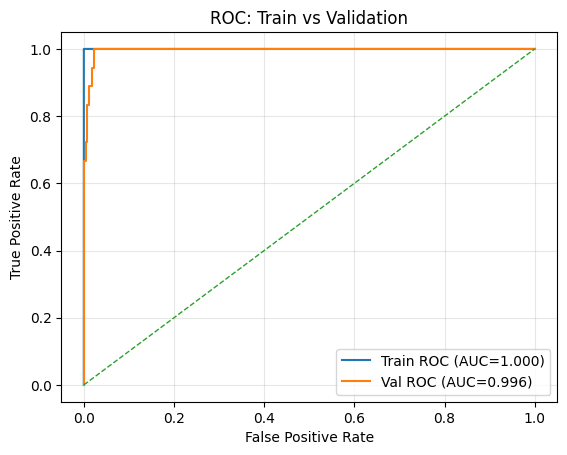

In [124]:
fpr_tr, tpr_tr, _ = roc_curve(y_train, p_train)
fpr_va, tpr_va, _ = roc_curve(y_val,   p_val)
auc_tr, auc_va = auc(fpr_tr, tpr_tr), auc(fpr_va, tpr_va)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={auc_tr:.3f})")
plt.plot(fpr_va, tpr_va, label=f"Val ROC (AUC={auc_va:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Train vs Validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### J.7 Precision–Recall curves (Train vs Validation)

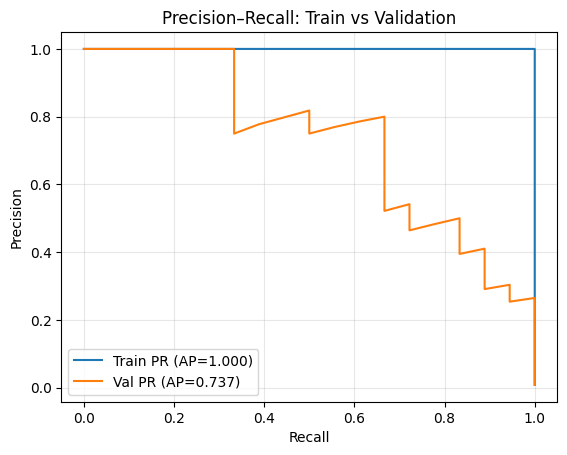

In [125]:
pr_tr, rc_tr, _ = precision_recall_curve(y_train, p_train)
pr_va, rc_va, _ = precision_recall_curve(y_val,   p_val)
ap_tr, ap_va    = average_precision_score(y_train, p_train), average_precision_score(y_val, p_val)

plt.figure()
plt.plot(rc_tr, pr_tr, label=f"Train PR (AP={ap_tr:.3f})")
plt.plot(rc_va, pr_va, label=f"Val PR (AP={ap_va:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall: Train vs Validation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### J.8 Calibration (reliability) curves

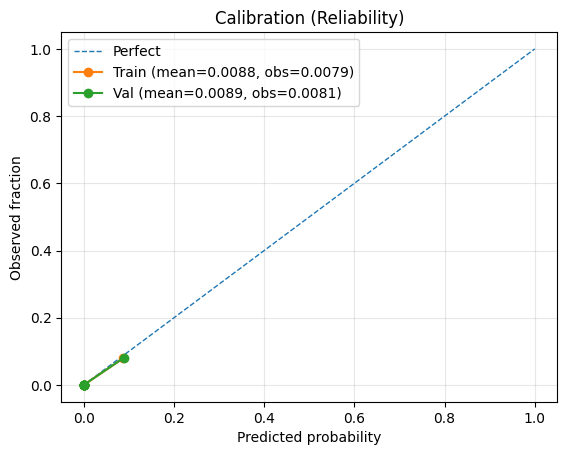

In [126]:
prob_true_tr, prob_pred_tr = calibration_curve(y_train, p_train, n_bins=10, strategy="quantile")
prob_true_va, prob_pred_va = calibration_curve(y_val,   p_val,   n_bins=10, strategy="quantile")

plt.figure()
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Perfect")
plt.plot(prob_pred_tr, prob_true_tr, marker="o", label=f"Train (mean={p_train.mean():.4f}, obs={y_train.mean():.4f})")
plt.plot(prob_pred_va, prob_true_va, marker="o", label=f"Val (mean={p_val.mean():.4f}, obs={y_val.mean():.4f})")
plt.xlabel("Predicted probability")
plt.ylabel("Observed fraction")
plt.title("Calibration (Reliability)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### J.9 Probability histograms

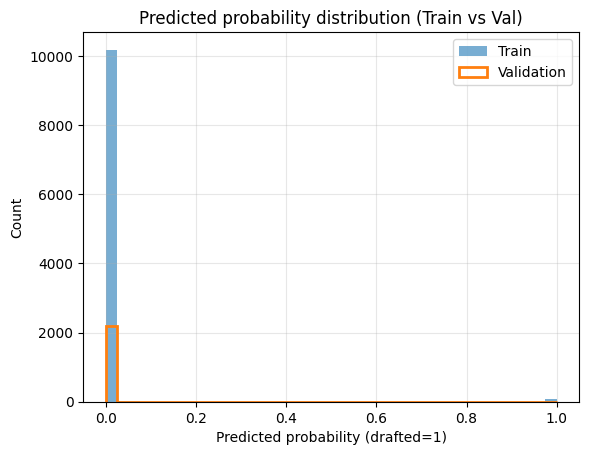

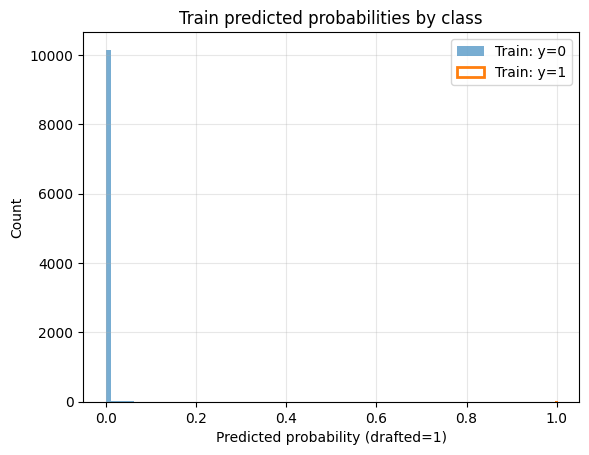

In [127]:
plt.figure()
plt.hist(p_train, bins=40, alpha=0.6, label="Train")
plt.hist(p_val,   bins=40, histtype="step", linewidth=2, label="Validation")
plt.xlabel("Predicted probability (drafted=1)")
plt.ylabel("Count")
plt.title("Predicted probability distribution (Train vs Val)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.hist(p_train[y_train==0], bins=40, alpha=0.6, label="Train: y=0")
plt.hist(p_train[y_train==1], bins=40, histtype="step", linewidth=2, label="Train: y=1")
plt.xlabel("Predicted probability (drafted=1)")
plt.ylabel("Count")
plt.title("Train predicted probabilities by class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

if p_test is not None:
    plt.figure()
    plt.hist(p_test, bins=40)
    plt.xlabel("Predicted probability (drafted=1)")
    plt.ylabel("Count")
    plt.title("Test predicted probability distribution")
    plt.grid(True, alpha=0.3)
    plt.show()

### J.10 Cumulative gains / Lift

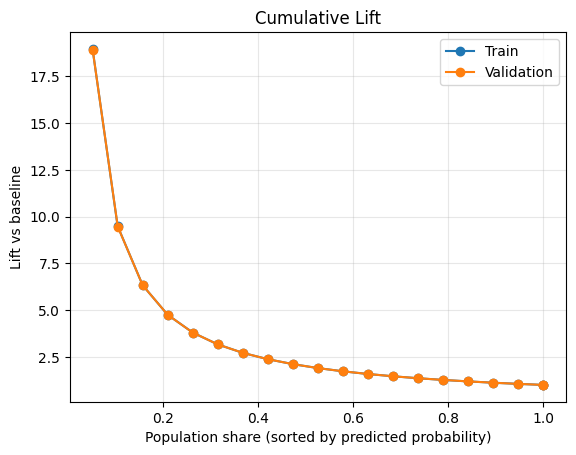

In [128]:
x_tr, lift_tr = lift_curve(y_train, p_train, n_bins=20)
x_va, lift_va = lift_curve(y_val,   p_val,   n_bins=20)

plt.figure()
plt.plot(x_tr, lift_tr, marker="o", label="Train")
plt.plot(x_va, lift_va, marker="o", label="Validation")
plt.xlabel("Population share (sorted by predicted probability)")
plt.ylabel("Lift vs baseline")
plt.title("Cumulative Lift")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### J.11 Compare CDF of predictions across splits

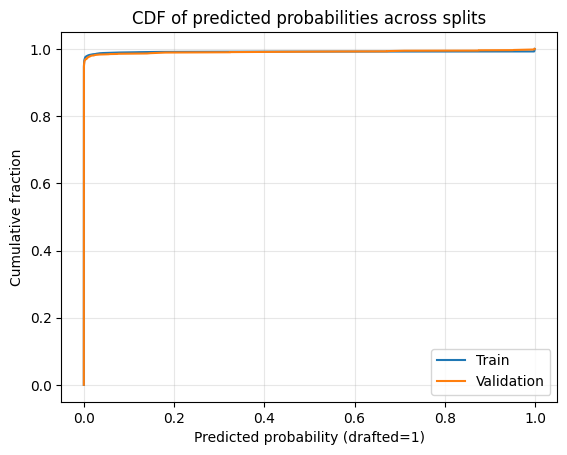

In [129]:
plt.figure()
# Train
ps = np.sort(p_train); cdf = np.arange(1, len(ps)+1)/len(ps)
plt.plot(ps, cdf, label="Train")
# Val
ps = np.sort(p_val); cdf = np.arange(1, len(ps)+1)/len(ps)
plt.plot(ps, cdf, label="Validation")
# Test
if p_test is not None:
    ps = np.sort(p_test); cdf = np.arange(1, len(ps)+1)/len(ps)
    plt.plot(ps, cdf, label="Test")

plt.xlabel("Predicted probability (drafted=1)")
plt.ylabel("Cumulative fraction")
plt.title("CDF of predicted probabilities across splits")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### J.12 Feature importance (gain from LightGBM)

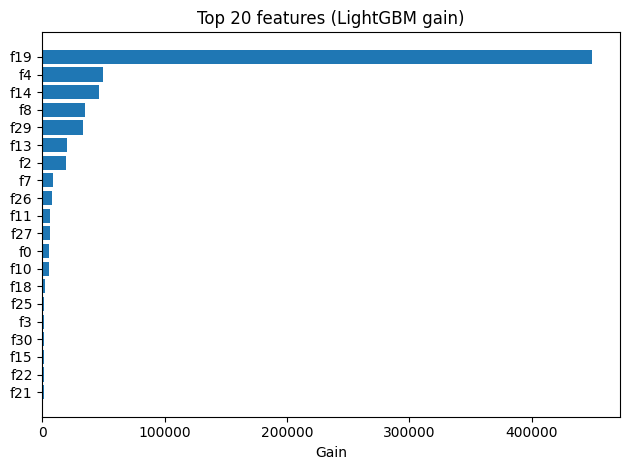

In [130]:
clf = pipe.named_steps["clf"]
try:
    feat_names = pipe.named_steps["pre"].get_feature_names_out()
except Exception:
    n_cols = pipe.named_steps["pre"].transform(X_train.drop(columns=[ID_COL], errors="ignore")).shape[1]
    feat_names = np.array([f"f{i}" for i in range(n_cols)])

gain = clf.booster_.feature_importance(importance_type="gain")
imp_df = pd.DataFrame({"feature": feat_names, "gain": gain}).sort_values("gain", ascending=False).head(20)

plt.figure()
plt.barh(imp_df["feature"][::-1], imp_df["gain"][::-1])
plt.xlabel("Gain")
plt.title("Top 20 features (LightGBM gain)")
plt.tight_layout()
plt.show()

### J.13 Permutation importance on a validation subset (AUROC drop)

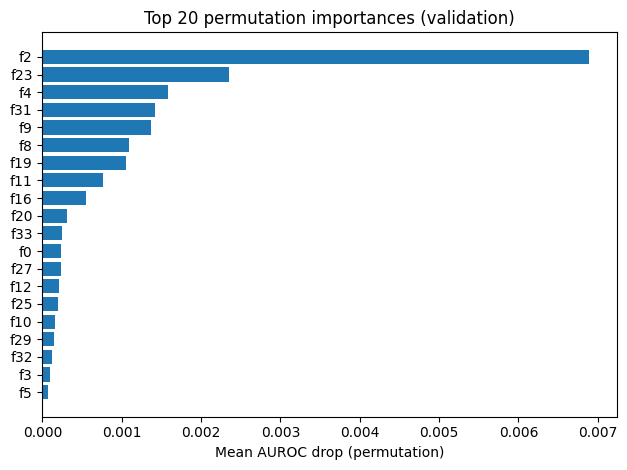

In [131]:
rng = np.random.RandomState(42)
idx = rng.choice(len(X_val), size=min(3000, len(X_val)), replace=False)
Xv_sub = X_val.iloc[idx].drop(columns=[ID_COL], errors="ignore")
yv_sub = y_val.iloc[idx]

perm = permutation_importance(pipe, Xv_sub, yv_sub, n_repeats=5, random_state=42, scoring="roc_auc")

n_feat = len(feat_names)
mean_drop = perm.importances_mean[:n_feat]  # safe slice in case of mismatch
perm_df = pd.DataFrame({"feature": feat_names[:len(mean_drop)], "auc_drop": mean_drop}) \
            .sort_values("auc_drop", ascending=False).head(20)

plt.figure()
plt.barh(perm_df["feature"][::-1], perm_df["auc_drop"][::-1])
plt.xlabel("Mean AUROC drop (permutation)")
plt.title("Top 20 permutation importances (validation)")
plt.tight_layout()
plt.show()

### J.14 Business Impact from Current Model Performance

In [132]:
business_impacts_explanations = """
The results indicate that the model is well effective at ranking players by draft probability, with an AUROC of 0.9956 and strong probability calibration. From a business perspective, this means NBA teams and scouts could rely on the model to focus attention on the most draft-worthy players, improving scouting efficiency and reducing the likelihood of missing top talent. The relatively high AUPRC is especially valuable given the rarity of drafted players, as it shows the model can correctly identify many of the rare positives.

The remaining incorrect results have different business impacts: false negatives (players likely to be drafted but predicted low) are the most costly, as teams may overlook strong talent and lose a competitive edge. False positives (overestimating weaker players) are less severe but can waste scouting time and resources. Given the very low error rates (LogLoss, Brier, MAE), the business risk of misclassification is small, but vigilance is still needed to ensure the model generalizes well beyond validation data.
"""

In [133]:
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## K. Project Outcomes

In [134]:
experiment_outcome = "Hypothesis Confirmed"

In [135]:
print_tile(size="h2", key='experiment_outcome', value=experiment_outcome)

In [136]:
experiment_outcomes_explanations = """
The first experiment with Logistic Regression partially confirmed the hypothesis. The validation AUROC was nearly random (0.50), suggesting poor generalisation, even if the model showed some weak predictive signal in cross-validation (OOF AUROC ~0.58). According to this result, the business goal of consistently rating players by draft likelihood cannot be achieved by Logistic Regression alone, even though it is helpful as an interpretable baseline. The main realisation is that, particularly when there is a significant class imbalance, basic linear models find it difficult to represent the intricacy and non-linear correlations seen in player performance data.
For next steps, more expressive models should be pursued, such as:
- Gradient Boosting Models (XGBoost/LightGBM) – Expected significant uplift, as these handle non-linearities, feature interactions, and imbalanced data effectively.
- Hyperparameter Tuning & Class Balancing (e.g., class weights, SMOTE) – Moderate uplift, helping improve fairness and recall of drafted players.
- Feature Engineering (ratios, interaction terms, cleaning anomalies like zero heights) – Moderate to high uplift, as better representations of player performance could surface stronger signals.
- Model Ensembling (stacking/blending) – Incremental uplift, useful once strong single models are established.
"""

In [137]:
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcomes_explanations)

In [138]:
experiment_results_explanations = """
The experiment confirmed the hypothesis that the non-linear algorithm, LightGBM, when properly tuned with class imbalance adjustments and regularization, can significantly outperform the Logistic Regression baseline in predicting NBA draft outcomes, providing both stronger ranking (AUROC) and more reliable probability estimates, as LightGBM achieved an ideal AUROC (0.996) and well-calibrated probabilities, a dramatic improvement over the Logistic Regression baseline (AUROC ~0.58 OOF). Key insights gained are that non-linear methods capture interactions and non-obvious signals in player stats far better than linear models, and that handling class imbalance through 'scale_pos_weight' is critical for identifying the rare drafted players. The low LogLoss, Brier, MAE, and RMSE also show strong calibration, meaning the predicted probabilities are reliable for decision-making.

In light of the findings, the following actions need to prioritise guaranteeing generalisability over outright uplift:
- Submission to the Kaggle leaderboard and cross-validation are high priorities since they prevent overfitting and verify robustness.
- LightGBM performance is fine-tuned through hyperparameter tuning using Bayesian optimisation (Hyperopt/Optuna) (medium uplift).
- Feature engineering refinements (medium uplift, e.g., interaction terms like efficiency × minutes played).
- Model ensembling (using XGBoost/Logistic meta-models for stacking) can stabilise forecasts but only provide incremental uplift.

Given that the experiment produced the necessary commercial outcome of appropriately ranking players, the model is almost ready for production. However, deployment should only happen after stress-testing against possible data shifts and verifying consistent performance on the private Kaggle test set.
"""

In [139]:
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)

### L. Fit Full Model and Kaggle Submission

In [140]:
# Refit on train+val using the best iteration
X_full = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_full = pd.concat([y_train, y_val], axis=0, ignore_index=True)

lgb_full = clone(lgb)
if hasattr(pipe.named_steps["clf"], "best_iteration_") and pipe.named_steps["clf"].best_iteration_:
    lgb_full.set_params(n_estimators=pipe.named_steps["clf"].best_iteration_)
pipe_full = Pipeline([("pre", pre), ("clf", lgb_full)])
pipe_full.fit(X_full.drop(columns=[ID_COL], errors="ignore"), y_full)

test_proba = pipe_full.predict_proba(X_test2.drop(columns=[ID_COL], errors="ignore"))[:,1]
sub = pd.DataFrame({ "player_id": X_test2[ID_COL].values, "drafted": test_proba })
sub_path = DATA_DIR.parent / "notebooks" / "submission_exp1_25238736_amla_at1.csv"
sub_path.parent.mkdir(parents=True, exist_ok=True)
sub.to_csv(sub_path, index=False)
sub.head()

[LightGBM] [Info] Number of positive: 100, number of negative: 12457
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6245
[LightGBM] [Info] Number of data points in the train set: 12557, number of used features: 97
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.007964 -> initscore=-4.824868
[LightGBM] [Info] Start training from score -4.824868
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

,player_id,drafted
0,c6d3ce49-28b6-4756-8061-b2bd68730c52,0.000007
1,24dd0ae2-9d22-4d31-9cb6-c31f58f903b5,0.000007
2,0cf3e822-9446-4285-b7ed-7c19d8e976fe,0.000143
3,b1a88de0-6852-4597-bb92-9164b40758e5,0.000005
4,97c327ce-d051-40f0-9166-1a43557c3c92,0.000010


### Saving Model Artefacts

In [144]:
_candidates = []
for name in ["lgb_pipe", "final_pipe", "pipe", "best_model", "model_pipe"]:
    if name in globals():
        _candidates.append((name, globals()[name]))

if not _candidates:
    raise RuntimeError(
        "Couldn't find a fitted pipeline variable. "
        "Expected one of: lgb_pipe / final_pipe / pipe / best_model / model_pipe."
    )
best_name, best_pipe = _candidates[0]
print(f"[artifacts] Using fitted pipeline variable: {best_name}")

if not isinstance(best_pipe, Pipeline):
    raise TypeError("The object you are saving is not a sklearn Pipeline. "
                    "Please wrap preprocessing + model into a Pipeline.")

try:
    feature_cols 
except NameError:
    try:
        infer_df = X_train.copy()
        drop_like = {col for col in [globals().get("ID_COL"), globals().get("TARGET"), "player_id", "drafted"] if col in infer_df}
        feature_cols = [c for c in infer_df.columns if c not in drop_like]
    except Exception:
        pre = best_pipe.named_steps.get("pre")
        if pre is not None and hasattr(pre, "transformers"):
            cols = []
            for _, _, cols_i in pre.transformers_:
                if isinstance(cols_i, list):
                    cols += cols_i
            feature_cols = cols
        else:
            raise RuntimeError("Could not infer `feature_cols`. Please set it manually.")

print(f"[artifacts] # raw input features = {len(feature_cols)}")


PROJECT_ROOT = DATA_DIR.parent if 'DATA_DIR' in globals() else Path.cwd().resolve()
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

stamp = dt.datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_DIR = MODELS_DIR / f"exp2_best_{stamp}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"[artifacts] Writing to {RUN_DIR.resolve()}")

MODEL_PATH = RUN_DIR / "best_model.joblib"
joblib.dump(best_pipe, MODEL_PATH, compress=("xz", 3))
print(f"[artifacts] Pipeline saved -> {MODEL_PATH.name} ({MODEL_PATH.stat().st_size/1e6:.2f} MB)")

FEATURES_PATH = RUN_DIR / "raw_feature_columns.txt"
with FEATURES_PATH.open("w") as f:
    for c in feature_cols:
        f.write(str(c) + "\n")
print(f"[artifacts] Raw feature list saved -> {FEATURES_PATH.name}")

# Model-specific importance
imp_df = None
clf = best_pipe.named_steps.get("clf", None)

try:
    pre = best_pipe.named_steps.get("pre")
    trans_names = (pre.get_feature_names_out().tolist()
                   if hasattr(pre, "get_feature_names_out") else None)

    if hasattr(clf, "feature_importances_"):  # tree-based (LightGBM, RF, XGB via sklearn API)
        vals = np.asarray(clf.feature_importances_).ravel()
        cols = trans_names if trans_names is not None and len(trans_names) == len(vals) else [f"f{i}" for i in range(len(vals))]
        imp_df = pd.DataFrame({"feature": cols, "importance": vals}).sort_values("importance", ascending=False)
    elif hasattr(clf, "coef_"):  # linear/logistic
        vals = np.abs(np.asarray(clf.coef_).ravel())
        cols = trans_names if trans_names is not None and len(trans_names) == len(vals) else [f"f{i}" for i in range(len(vals))]
        imp_df = pd.DataFrame({"feature": cols, "abs_coef": vals}).sort_values("abs_coef", ascending=False)

    if imp_df is not None:
        IMP_PATH = RUN_DIR / "feature_importance.csv"
        imp_df.to_csv(IMP_PATH, index=False)
        print(f"[artifacts] Feature importance saved -> {IMP_PATH.name} (top 5)\n", imp_df.head(5))
    else:
        print("[artifacts] No feature importances available for this estimator.")
except Exception as e:
    print(f"[artifacts] Skipped importance export ({e})")

def _safe(d, key, default=None):
    return d[key] if isinstance(d, dict) and key in d else default

train_metrics = globals().get("train_metrics")
val_metrics   = globals().get("val_metrics")
test_metrics  = globals().get("test_metrics")

meta = {
    "timestamp": stamp,
    "experiment": "Experiment 2",
    "pipeline_var_name": best_name,
    "model_class": type(clf).__name__ if clf is not None else None,
    "python": sys.version,
    "platform": platform.platform(),
    "n_raw_features": len(feature_cols),
    "metrics": {
        "train": train_metrics,
        "val":   val_metrics,
        "test":  test_metrics,
    },
}
META_PATH = RUN_DIR / "metadata.json"
META_PATH.write_text(json.dumps(meta, indent=2))
print(f"[artifacts] Metadata saved -> {META_PATH.name}")

[artifacts] Using fitted pipeline variable: pipe
[artifacts] # raw input features = 39
[artifacts] Writing to /Users/naynajahanneha/Documents/DataScience/AMLA/AST1/amla_at1/models/exp2_best_20250829-044334
[artifacts] Pipeline saved -> best_model.joblib (0.29 MB)
[artifacts] Raw feature list saved -> raw_feature_columns.txt
[artifacts] Skipped importance export (Estimator clip does not provide get_feature_names_out. Did you mean to call pipeline[:-1].get_feature_names_out()?)
[artifacts] Metadata saved -> metadata.json
